## Natural Language Processing (NLP) II in Finance

This notebook applies Latent Dirichlet Allocation (LDA) topic modelling (Lecture 6, Technical Appendix B)
to the **risk factors (Item 1A)** of 10-K filings. We will:

- **Preprocess** the risk-factor sections with the same pipeline as Notebook I
- **Build** the vocabulary and document-term matrix, pruning rare and near-universal terms
- **Estimate LDA** and choose the number of topics using held-out perplexity
- **Visualise** the topics, their **attention** over time and how they line up with industries

#### Required Packages

* **nltk** - Tokenisation, stop words, part-of-speech tagging and lemmatisation (see https://www.nltk.org)
* **gensim** - Topic modelling (see https://radimrehurek.com/gensim/)
* **pyLDAvis** - Interactive topic model visualisation (see https://pyldavis.readthedocs.io)
* **requests** - Downloading the 10-K filings
* **pandas & numpy** - Data manipulation and numerical computing
* **matplotlib, seaborn & wordcloud** - Data visualisation

```
pip install nltk gensim pyLDAvis requests pandas numpy matplotlib seaborn wordcloud
```

In [1]:
import gzip, json, os, time
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import requests

# NLP toolkits
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from gensim import corpora, matutils, models
from gensim.models import Phrases
from gensim.models.phrases import ENGLISH_CONNECTOR_WORDS

# Graphics packages
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [2]:
for package in ["punkt_tab", "stopwords", "wordnet", "averaged_perceptron_tagger_eng"]:
    nltk.download(package, quiet=True)

#### Analysis Settings

Choose the sample **before** running the analysis. Filings are drawn at random (with a fixed seed), as in
Notebook I. Item 1A became mandatory in 10-Ks for fiscal years ending on or after 1 December 2005, so the sample
starts with filings made in 2006. Preprocessing is the slowest step (roughly 2 minutes per 1,000 filings), and
memory use grows with the sample (allow ~4 GB per 10,000 filings).

- `N_FILINGS` - number of 10-K filings to sample (`None` = all filings in the selected years)
- `START_YEAR`, `END_YEAR` - filing years to include (2006-2021)
- `TOPIC_GRID` - numbers of topics $K$ to compare using held-out perplexity
- `MIN_IMPROVEMENT` - elbow rule: choose the first $K$ after which the next $K$ in `TOPIC_GRID` improves held-out perplexity by less than this share
- `N_TOPICS` - set an integer to override the choice of $K$ (`None` = choose $K$ by held-out perplexity)

In [3]:
N_FILINGS = 10000              # number of 10-K filings to sample; None = all filings
START_YEAR = 2006              # first filing year (first 10-Ks with a mandatory Item 1A)
END_YEAR = 2021                # last filing year
SEED = 42                      # random seed for reproducible sampling and estimation
TOPIC_GRID = [5, 10, 15, 20, 25, 30, 35, 40]   # numbers of topics K to compare
MIN_IMPROVEMENT = 0.01         # elbow rule: stop when the next K improves held-out perplexity by less than 1%
N_TOPICS = None                # e.g. 10 to fix K; None = choose K by held-out perplexity

assert 2006 <= START_YEAR <= END_YEAR <= 2021

#### Text Data

**US Public Firm Annual Reports (10-K)** (`JanosAudran/financial-reports-sec`)
- **Description**: 10-K filings from SEC EDGAR split into their items (EDGAR-CORPUS; Loukas et al., 2021)
- **Size**: ~55,000 filings from ~4,700 firms (~12 GB)
- **Use Case**: Discovering the types of risk that firms disclose
- **Download**: https://huggingface.co/datasets/JanosAudran/financial-reports-sec

The filings are downloaded with the same function as in Notebook I: chunks of the data files (which are
sorted by firm) are read in random order until `N_FILINGS` filings are collected, and all of a sampled firm's
filings in the period are kept. A chunk that fails because of a network error is retried up to five times.
The filings are cached to disk, so re-running the notebook does not download them again.

In [4]:
REPO = "https://huggingface.co/{}datasets/JanosAudran/financial-reports-sec/{}"
CHUNK_BYTES = 20_000_000
RETRIES = 5  # attempts per request before the download stops


def with_retries(fetch, *args):
    # Call fetch(*args), retrying after network errors with waits of 2, 4, 8 and 16 seconds
    for attempt in range(1, RETRIES + 1):
        try:
            return fetch(*args)
        except requests.RequestException as error:
            if attempt == RETRIES:
                raise
            print(f"\nNetwork error ({type(error).__name__}), attempt {attempt} of {RETRIES}; retrying")
            time.sleep(2 ** attempt)


def list_files():
    # (URL, size) of each data file in the dataset's train, validation and test splits
    files = []
    for split in ("train", "validate", "test"):
        r = requests.get(REPO.format("api/", "tree/main/data/large/" + split), timeout=60)
        r.raise_for_status()
        files += [(REPO.format("", "resolve/main/" + f["path"]), f.get("lfs", f)["size"]) for f in r.json()]
    return files


def read_chunk(url, start, end):
    # Firm records whose lines start within bytes [start, end) of a data file; a retry re-reads the whole chunk
    first = max(start - 1, 0)  # begin one byte early, so a record starting exactly at `start` is kept
    firms, buf, pos, skip = [], b"", first, start > 0
    with requests.get(url, headers={"Range": f"bytes={first}-"}, stream=True, timeout=300) as r:
        r.raise_for_status()
        for block in r.iter_content(chunk_size=1 << 20):
            buf += block
            while (nl := buf.find(b"\n")) >= 0:
                if not skip:  # the first partial record belongs to the previous chunk
                    firms.append(json.loads(buf[:nl]))
                skip, pos, buf = False, pos + nl + 1, buf[nl + 1:]
                if pos >= end:
                    return firms
    if buf.strip() and not skip:  # last record in the file
        firms.append(json.loads(buf))
    return firms


def load_10k_filings(n_filings, start_year, end_year, seed, cache_dir="data"):
    # Sample n_filings 10-Ks filed in [start_year, end_year] (None = all); cache them and return the cache path
    path = f"{cache_dir}/10k_{start_year}-{end_year}_" + ("all" if n_filings is None else f"n{n_filings}_seed{seed}") + ".jsonl.gz"
    if os.path.exists(path):
        return path
    os.makedirs(cache_dir, exist_ok=True)
    chunks = [(url, a, a + CHUNK_BYTES) for url, size in with_retries(list_files) for a in range(0, size, CHUNK_BYTES)]
    order = np.random.default_rng(seed).permutation(len(chunks))  # random order, without replacement
    target = n_filings or float("inf")
    n, seen = 0, set()
    with gzip.open(path + ".part", "wt", compresslevel=3) as out, ThreadPoolExecutor(max_workers=8) as pool:
        for b in range(0, len(order), 8):
            for firms in pool.map(lambda c: with_retries(read_chunk, *c), [chunks[i] for i in order[b:b + 8]]):
                for firm in firms:
                    for f in firm["filings"]:
                        doc_id = f"{firm['cik']}_{f['reportDate'][:4]}"
                        if n < target and start_year <= int(f["filingDate"][:4]) <= end_year and doc_id not in seen:
                            seen.add(doc_id)
                            n += 1
                            out.write(json.dumps({"docID": doc_id, "cik": firm["cik"], "name": firm["name"],
                                                  "sic": firm["sic"], "exchanges": firm["exchanges"],
                                                  **{k: f[k] for k in ("filingDate", "labels", "returns", "report")}}) + "\n")
            print(f"\rRead {min(b + 8, len(order))} / {len(order)} chunks: {n:,} filings", end="")
            if n >= target:
                break
    if n_filings is not None and n < n_filings:
        print(f"\nOnly {n:,} filings were filed in {start_year}-{end_year}; all of them are used")
    os.rename(path + ".part", path)
    return path

### Text as Data: Item 1A Risk Factors

Item 1A discusses the most significant factors that make an investment in the firm speculative or risky.
Each risk-factor section is one document $d_i$. Smaller reporting companies are not required to provide
Item 1A, and many state only that, so sections with fewer than 500 words are dropped.

In [5]:
CACHE = load_10k_filings(N_FILINGS, START_YEAR, END_YEAR, SEED)


def iter_filings():
    # Stream the cached filings one at a time (the full text of every filing would use a lot of memory)
    with gzip.open(CACHE, "rt") as fh:
        for line in fh:
            yield json.loads(line)


MIN_WORDS = 500
records = []
for f in iter_filings():
    text = " ".join(f["report"].get("section_1A") or [])
    if len(text.split()) >= MIN_WORDS:
        records.append({"docID": f["docID"], "cik": f["cik"], "name": f["name"], "sic": f["sic"],
                        "filingDate": f["filingDate"], "text": text})

df_docs = pd.DataFrame(records)
df_docs["filingDate"] = pd.to_datetime(df_docs["filingDate"])
docs = df_docs.pop("text").tolist()

print(f"\n{len(docs):,} of {N_FILINGS:,} filings have an Item 1A of at least {MIN_WORDS} words "
      f"({df_docs.cik.nunique()} firms, median {np.median([len(d.split()) for d in docs]):,.0f} words)")
print(f"\nExample ({df_docs.name[0]}, filed {df_docs.filingDate[0]:%Y-%m-%d}):\n{docs[0][:600]} ...")


8,763 of 10,000 filings have an Item 1A of at least 500 words (993 firms, median 6,984 words)

Example (Redfin Corp, filed 2021-02-24):
Item 1A. Risk Factors You should carefully consider the risks described below, together with all other information in this annual report, before investing in any of our securities. The occurrence of any single risk or any combination of risks could materially and adversely affect our business, operating results, financial condition, liquidity, or competitive position, and consequently, the value of our securities. The material adverse effects include, but are not limited to, not growing our revenue or market share at the pace that they have grown historically or at all, our revenue and market  ...


#### Text Preprocessing for Financial Data

We use the same pipeline as Notebook I and Lecture 6 (Technical Appendix A): tokenise, lowercase, drop numbers,
punctuation and stop words, and lemmatise. Frequent word pairs are then joined into bigrams
(e.g. `clinical_trial`, `interest_rate`), as in the uni- and bigram topic model of the Wall Street Journal in the lecture.

In [6]:
STOP = set(stopwords.words("english")) - {"not", "no", "nor", "will"}  # keep negation/modals
POS = {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}           # Penn tag -> WordNet tag
stemmer, lemmatiser = PorterStemmer(), WordNetLemmatizer()


def preprocess(doc, method="lemma"):
    out = []
    for token, tag in nltk.pos_tag(nltk.word_tokenize(doc)):  # tokenise, tag part of speech
        token = token.lower()                                 # lowercase
        if not token.isalpha() or token in STOP:              # drop numbers, punctuation, stop words
            continue
        if method == "stem":
            out.append(stemmer.stem(token))
        else:
            out.append(lemmatiser.lemmatize(token, POS.get(tag[0], wordnet.NOUN)))
    return out


texts = []
for i, doc in enumerate(docs, 1):
    texts.append(preprocess(doc))
    if i % 500 == 0 or i == len(docs):
        print(f"\rPreprocessed {i:,} / {len(docs):,} documents", end="")

bigram = Phrases(texts, min_count=20, threshold=10, connector_words=ENGLISH_CONNECTOR_WORDS).freeze()
texts = [bigram[t] for t in texts]
print("\n\nExample bigrams:", sorted({w for t in texts[:20] for w in t if "_" in w})[:15])

Preprocessed 8,763 / 8,763 documents

Example bigrams: ['aberration_distortion', 'accelerate_filer', 'accommodate_sudden', 'accountant_adviser', 'accounting_firm', 'accrued_unpaid', 'accumulate_communicate', 'accurately_forecast', 'act_god', 'active_trading', 'adjust_reallocate', 'advance_notice', 'advanced_persistent', 'affair_doctrine', 'aggregate_principal']


#### Bag of Words: Vocabulary and Corpus

The gensim `Dictionary` is the vocabulary $\mathcal{V}$, and `doc2bow` turns each document into its row of
the document-term matrix (a sparse list of term counts).

To evaluate the topic models below, 20% of the **firms** are held out. Whole firms are held out, rather than
individual filings, because a firm's Item 1A changes little from year to year, so the held-out documents must
come from firms the model has not seen. The vocabulary is built from the training firms only, pruning three
kinds of terms:

- **Firm-specific terms**: used by fewer than 5 firms (e.g. company and product names). Firms repeat much of
  Item 1A every year, so without this filter topics can capture individual firms
- **Rare terms**: in fewer than 10 documents
- **Near-universal terms**: in more than 50% of documents (e.g. "risk", "business"), which act as corpus-specific stop words

In [7]:
MIN_FIRMS = 5
HELD_OUT_SHARE = 0.2   # share of firms held out to evaluate the topic models

# Hold out whole firms (not filings), because a firm's Item 1A changes little from year to year
firms = df_docs["cik"].unique()
held_out_firms = np.random.default_rng(SEED).choice(firms, int(HELD_OUT_SHARE * len(firms)), replace=False)
held_out = df_docs["cik"].isin(held_out_firms).to_numpy()

# Vocabulary from the training firms only
train_texts = [t for t, h in zip(texts, held_out) if not h]
dictionary = corpora.Dictionary(train_texts)
n_terms = len(dictionary)

firm_vocab = {}
for cik, tokens in zip(df_docs.loc[~held_out, "cik"], train_texts):
    firm_vocab.setdefault(cik, set()).update(tokens)
firm_count = Counter(w for vocab in firm_vocab.values() for w in vocab)
dictionary.filter_tokens(bad_ids=[i for w, i in dictionary.token2id.items() if firm_count[w] < MIN_FIRMS])
dictionary.filter_extremes(no_below=10, no_above=0.5, keep_n=None)

corpus = [dictionary.doc2bow(t) for t in texts]   # all documents
nnz = sum(len(bow) for bow in corpus)
print(f"Training firms: {len(firms) - len(held_out_firms):,} ({(~held_out).sum():,} documents); "
      f"held-out firms: {len(held_out_firms):,} ({held_out.sum():,} documents)")
print(f"Vocabulary: {n_terms:,} terms -> {len(dictionary):,} after pruning")
print(f"Document-term matrix: {len(corpus):,} documents x {len(dictionary):,} terms, "
      f"{nnz / (len(corpus) * len(dictionary)):.1%} of entries non-zero")

Training firms: 795 (7,098 documents); held-out firms: 198 (1,665 documents)
Vocabulary: 42,843 terms -> 14,104 after pruning
Document-term matrix: 8,763 documents x 14,104 terms, 3.9% of entries non-zero


#### Latent Dirichlet Allocation (LDA) Topic Modelling

**LDA Overview** (Lecture 6, Technical Appendix B):
* Each **topic** $k$ is a distribution $\boldsymbol\phi_k$ over the vocabulary
* Each **document** $d$ has topic proportions $\boldsymbol\theta_d$, so a risk-factor section mixes several types of risk
* Dirichlet priors $\boldsymbol\alpha$ (on $\boldsymbol\theta_d$) and $\boldsymbol\eta$ (on $\boldsymbol\phi_k$) are learned from the data (`alpha="auto"`, `eta="auto"`)

**Model Parameters:**
* `num_topics` - the number of topics $K$, chosen below
* `passes=10` - number of passes through the corpus during estimation
* `random_state=SEED` - for reproducible results

#### Choosing the Number of Topics: Held-out Perplexity

As in Lecture 6 (Technical Appendix B), models with different $K$ are compared by how well they predict the
words of documents they have not seen. Each model is estimated on the training firms, and its **held-out
perplexity** is computed on the held-out firms:
$$\text{Perplexity}(\mathcal{D}_{\text{test}}) = \exp\left(-\frac{\sum_{d \in \mathcal{D}_{\text{test}}} \log p(\mathbf{w}_d)}{\sum_{d \in \mathcal{D}_{\text{test}}} N_d}\right)$$
Lower values mean better predictive fit. A held-out document's topic proportions $\boldsymbol\theta_d$ are unknown,
so we use **document completion**: $\boldsymbol\theta_d$ is inferred from every other word
of the document, and the perplexity is computed on the remaining words, with $p(w \mid d) = \sum_k \theta_{dk}\,\phi_{kw}$.

Held-out perplexity often keeps falling slowly as $K$ grows, so we choose the **elbow**: the first $K$ in
`TOPIC_GRID` after which moving to the next $K$ improves held-out perplexity by less than `MIN_IMPROVEMENT` (1%),
or the $K$ with the lowest perplexity if it starts rising first. The chosen model is then re-estimated on all
documents. Perplexity measures predictive fit, not interpretability, so the topics are
inspected below.

K =  5: held-out perplexity = 2,193.7
K = 10: held-out perplexity = 2,024.6
K = 15: held-out perplexity = 1,961.3
K = 20: held-out perplexity = 1,894.2
K = 25: held-out perplexity = 1,864.1
K = 30: held-out perplexity = 1,848.6
K = 35: held-out perplexity = 1,826.3
K = 40: held-out perplexity = 1,799.9


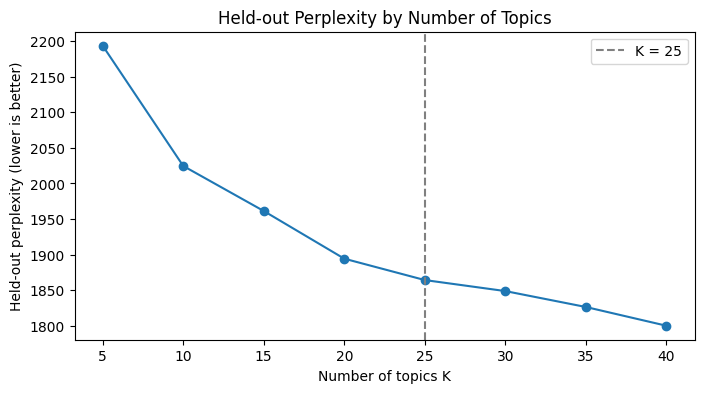

In [8]:
train_corpus = [bow for bow, h in zip(corpus, held_out) if not h]
held_out_texts = [t for t, h in zip(texts, held_out) if h]
observed = [dictionary.doc2bow(t[0::2]) for t in held_out_texts]                  # half used to infer theta_d
evaluated = matutils.corpus2csc([dictionary.doc2bow(t[1::2]) for t in held_out_texts],
                                num_terms=len(dictionary)).T.tocsr()               # other half used to evaluate


def heldout_perplexity(model):
    # Document completion: infer theta_d from the observed half of each document, then score the other half
    gamma, _ = model.inference(observed)
    theta = gamma / gamma.sum(axis=1, keepdims=True)       # topic proportions, D_test x K
    phi = model.get_topics().astype(float)                 # topic-word distributions, K x V
    log_lik = 0.0
    for a in range(0, evaluated.shape[0], 500):
        p = np.einsum("dk,kv->dv", theta[a:a + 500], phi)   # p(w | d) = sum_k theta_dk * phi_kw
        log_lik += evaluated[a:a + 500].multiply(np.log(p)).sum()
    return np.exp(-log_lik / evaluated.sum())


scores = {}
for k in TOPIC_GRID:
    model = models.LdaModel(corpus=train_corpus, id2word=dictionary, num_topics=k, passes=10,
                            alpha="auto", eta="auto", random_state=SEED)
    scores[k] = heldout_perplexity(model)
    print(f"K = {k:>2}: held-out perplexity = {scores[k]:,.1f}")
scores = pd.Series(scores)

# Elbow rule: the first K after which the next K improves held-out perplexity by less than MIN_IMPROVEMENT
improvement = 1 - scores.shift(-1) / scores
K = N_TOPICS or int(next((k for k in scores.index[:-1] if improvement[k] < MIN_IMPROVEMENT), scores.idxmin()))

# Re-estimate the chosen model on all documents
lda_model = models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=K, passes=10,
                            alpha="auto", eta="auto", random_state=SEED)

plt.figure(figsize=(8, 4))
plt.plot(scores.index, scores.values, marker="o")
plt.axvline(K, color="grey", linestyle="--", label=f"K = {K}")
plt.title("Held-out Perplexity by Number of Topics")
plt.xlabel("Number of topics K")
plt.ylabel("Held-out perplexity (lower is better)")
plt.legend()
plt.show()

### Topic Visualisation

1. **Top Terms and Word Clouds** - the most probable words in each topic
2. **Topic Attention** - how much risk-factor text covers each topic over time
3. **Topics by Industry** - whether the topics line up with the firms' industries
4. **Interactive LDA Visualisation** - pyLDAvis for exploring topics and terms

#### Top Terms for Each Topic

Topics are numbered 1 to $K$ (as in pyLDAvis below) and labelled by their three most probable terms.

In [9]:
top_terms = {k: [w for w, _ in lda_model.show_topic(k, 10)] for k in range(K)}
topic_labels = {k: f"T{k + 1}: " + ", ".join(terms[:3]) for k, terms in top_terms.items()}

pd.DataFrame({f"Topic {k + 1}": terms for k, terms in top_terms.items()}, index=range(1, 11)).T

,1,2,3,4,5,6,7,8,9,10
Topic 1,candidate,patent,clinical_trial,drug,fda,clinical,commercialize,patient,commercialization,research
Topic 2,patent,fda,reimbursement,clinical,patient,laboratory,payer,healthcare,research,study
Topic 3,gas,oil,natural_gas,oil_natural,drilling,crude_oil,exploration,drill,commodity,hydraulic_fracturing
Topic 4,card,bank,merchant,processing,atm,money,institution,electronic,card_association,fraud
Topic 5,software,solution,platform,user,privacy,communication,internet,content,patent,vendor
Topic 6,portfolio,reit,real_estate,tenant,lease,loan,preferred,indebtedness,manager,lender
Topic 7,china,prc,chinese,safe,enterprise,dollar,direct_selling,registration,court,mainland_china
Topic 8,indebtedness,home,construction,land,covenant,mortgage,lender,repurchase,rating,impairment
Topic 9,preferred,penny,exercise,research,series_preferred,warrant,conversion,convertible,history,go_concern
Topic 10,food,animal,fda,raw_material,barda,manufacture,recall,drug,ingredient,human


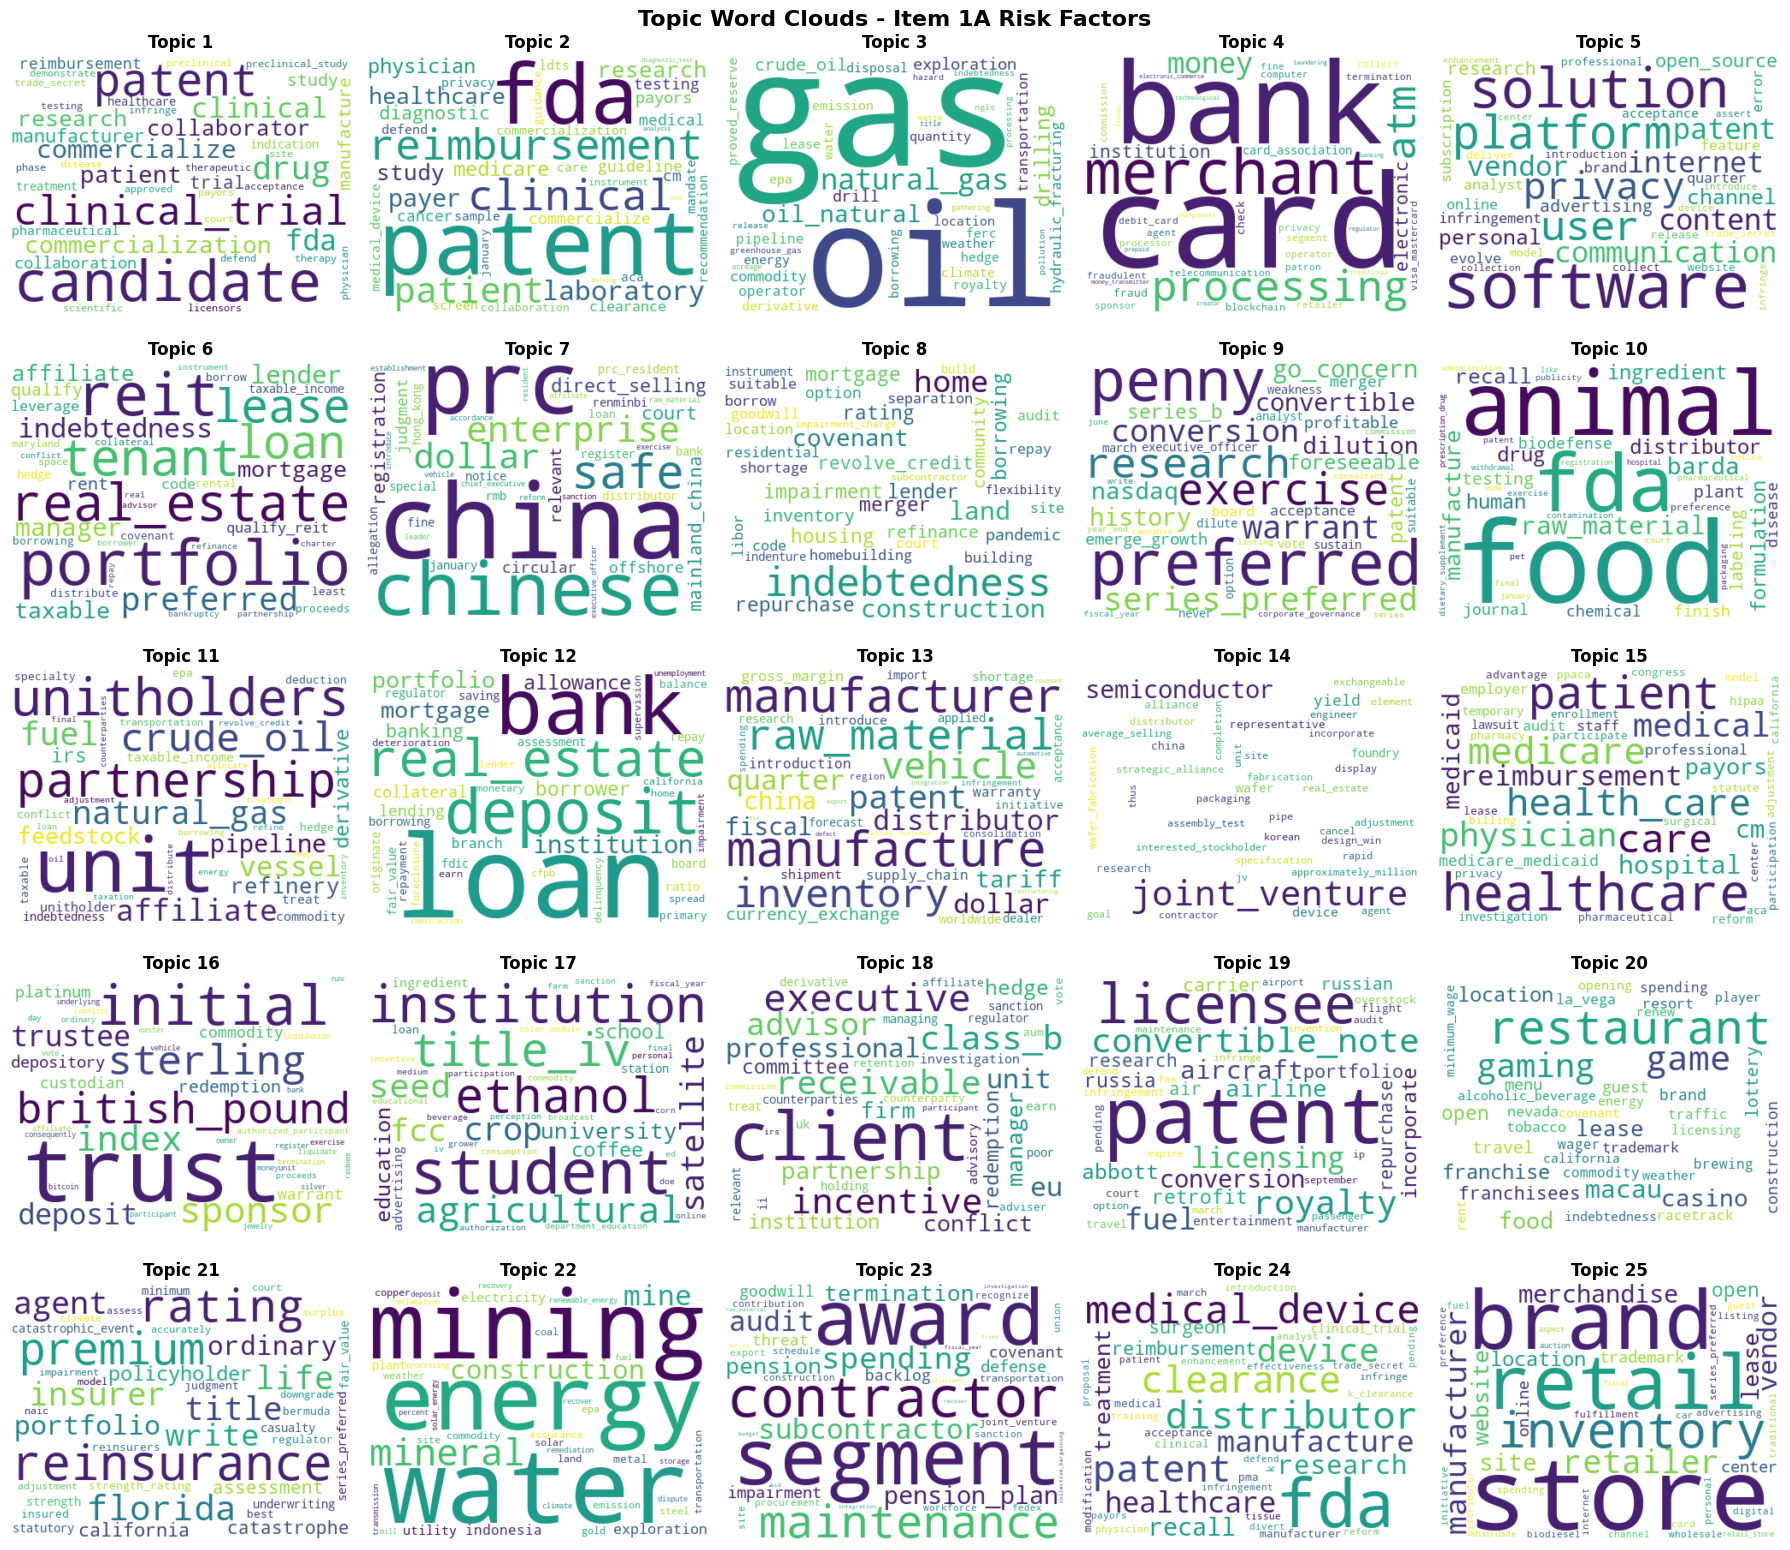

In [10]:
ncols = 5
nrows = int(np.ceil(K / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.2 * nrows))
for k, ax in enumerate(np.ravel(axes)):
    ax.axis("off")
    if k < K:
        wordcloud = WordCloud(width=400, height=300, background_color="white", colormap="viridis",
                              random_state=SEED).generate_from_frequencies(dict(lda_model.show_topic(k, 40)))
        ax.imshow(wordcloud, interpolation="bilinear")
        ax.set_title(f"Topic {k + 1}", fontweight="bold")
fig.suptitle("Topic Word Clouds - Item 1A Risk Factors", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

#### Topic Attention Over Time

As in the lecture, **attention** is the proportion of text covering a topic at time $t$: the average of the
topic proportions $\theta_{dk}$ across filings in year $t$, weighted by document length. With a panel of firms,
changes in attention reflect both changes in what firms disclose and changes in which firms are in the sample.

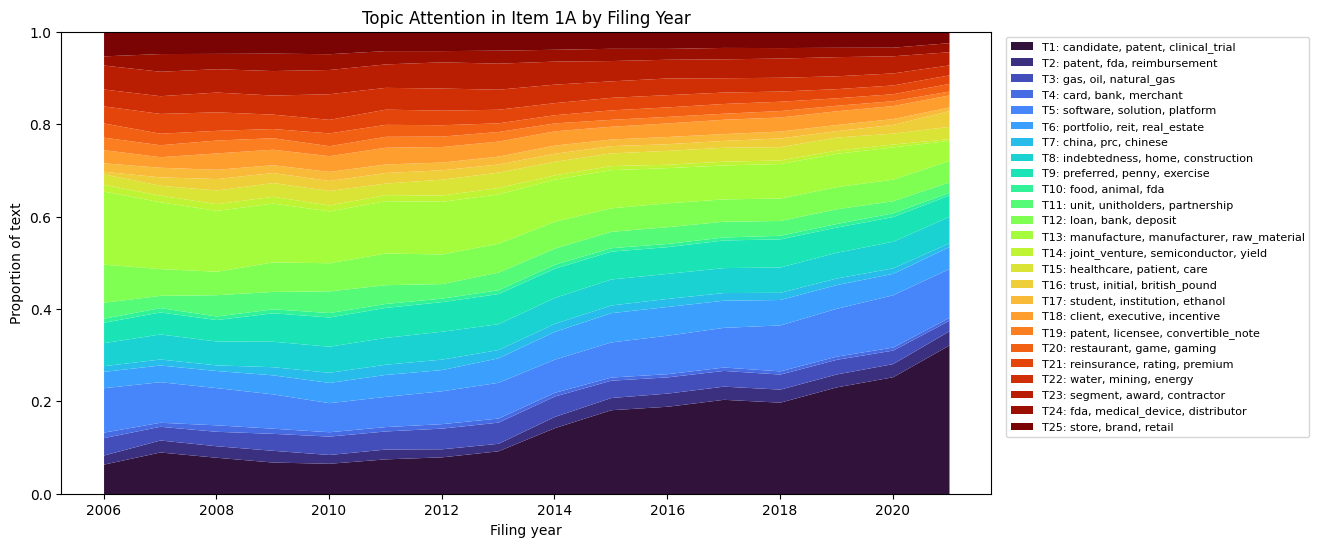

Filings per year: {2006: 294, 2007: 340, 2008: 385, 2009: 420, 2010: 422, 2011: 437, 2012: 481, 2013: 521, 2014: 572, 2015: 615, 2016: 636, 2017: 658, 2018: 718, 2019: 739, 2020: 800, 2021: 725}


In [11]:
theta = np.zeros((len(corpus), K))   # document-topic proportions
for i, bow in enumerate(corpus):
    for k, p in lda_model.get_document_topics(bow, minimum_probability=0.0):
        theta[i, k] = p

df_theta = pd.DataFrame(theta, columns=[topic_labels[k] for k in range(K)])
year = df_docs["filingDate"].dt.year.values
length = pd.Series([sum(n for _, n in bow) for bow in corpus])
attention = df_theta.mul(length, axis=0).groupby(year).sum().div(length.groupby(year).sum(), axis=0)

ax = attention.plot.area(figsize=(12, 6), colormap="tab20" if K <= 20 else "turbo", linewidth=0)
ax.set(title="Topic Attention in Item 1A by Filing Year", xlabel="Filing year", ylabel="Proportion of text", ylim=(0, 1))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.show()
print("Filings per year:", pd.Series(year).value_counts().sort_index().to_dict())

#### Topics by Industry

A simple validity check: if the topics capture real types of risk, they should differ across industries.
Firms are grouped into SIC divisions, and the heatmap shows the average topic proportions in each division
(divisions with at least 20 filings).

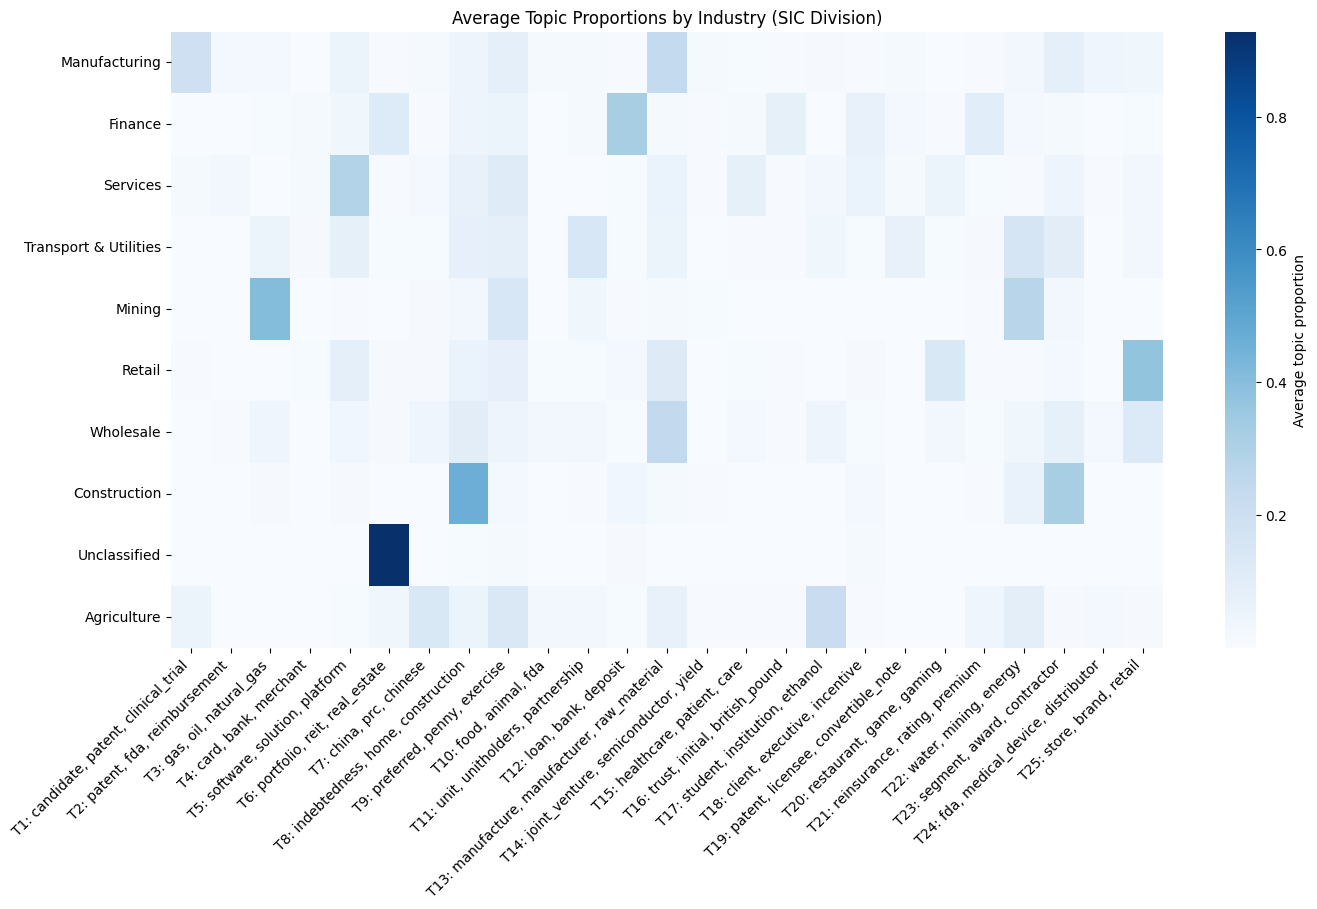

In [12]:
SIC_DIVISIONS = [(1, 9, "Agriculture"), (10, 14, "Mining"), (15, 17, "Construction"), (20, 39, "Manufacturing"),
                 (40, 49, "Transport & Utilities"), (50, 51, "Wholesale"), (52, 59, "Retail"),
                 (60, 67, "Finance"), (70, 89, "Services"), (91, 99, "Public Administration")]


def sic_division(sic):
    major = int(sic) // 100 if str(sic).isdigit() else -1
    return next((name for lo, hi, name in SIC_DIVISIONS if lo <= major <= hi), "Unclassified")


df_docs["industry"] = df_docs["sic"].apply(sic_division)
counts = df_docs["industry"].value_counts()
by_industry = df_theta.groupby(df_docs["industry"].values).mean().loc[counts[counts >= 20].index]

plt.figure(figsize=(16, 0.6 * len(by_industry) + 2))
sns.heatmap(by_industry, cmap="Blues", annot=K <= 20, fmt=".2f", cbar_kws={"label": "Average topic proportion"})
plt.title("Average Topic Proportions by Industry (SIC Division)")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.show()

#### Enriching the Dataset with Topic Inferences

Adding the topic proportions to the filing-level data allows them to be used in further analysis, e.g. as
features in a model of returns or volatility, or to compare firms' risk profiles.

In [13]:
for k in range(K):
    df_docs[f"Topic_{k + 1}_Proportion"] = theta[:, k]
df_docs["Dominant_Topic"] = theta.argmax(axis=1) + 1
df_docs["Dominant_Topic_Label"] = [topic_labels[k] for k in theta.argmax(axis=1)]
df_docs["Dominant_Topic_Probability"] = theta.max(axis=1)

print("Dominant topic distribution:")
print(df_docs["Dominant_Topic_Label"].value_counts().to_string())
df_docs[["name", "filingDate", "industry", "Dominant_Topic_Label", "Dominant_Topic_Probability"]].head()

Dominant topic distribution:
Dominant_Topic_Label
T13: manufacture, manufacturer, raw_material    1438
T1: candidate, patent, clinical_trial            866
T5: software, solution, platform                 808
T9: preferred, penny, exercise                   741
T12: loan, bank, deposit                         599
T8: indebtedness, home, construction             419
T23: segment, award, contractor                  404
T22: water, mining, energy                       394
T6: portfolio, reit, real_estate                 368
T25: store, brand, retail                        354
T3: gas, oil, natural_gas                        305
T21: reinsurance, rating, premium                214
T20: restaurant, game, gaming                    204
T18: client, executive, incentive                202
T11: unit, unitholders, partnership              199
T24: fda, medical_device, distributor            194
T17: student, institution, ethanol               184
T15: healthcare, patient, care                   

,name,filingDate,industry,Dominant_Topic_Label,Dominant_Topic_Probability
0,Redfin Corp,2021-02-24,Finance,"T5: software, solution, platform",0.313094
1,Redfin Corp,2020-02-12,Finance,"T5: software, solution, platform",0.355719
2,Redfin Corp,2019-02-14,Finance,"T5: software, solution, platform",0.501035
3,Redfin Corp,2018-02-22,Finance,"T5: software, solution, platform",0.467399
4,INVESCO DB US DOLLAR INDEX BEARISH FUND,2021-02-26,Finance,"T16: trust, initial, british_pound",0.588965


#### Interactive Topic Visualisation with pyLDAvis

pyLDAvis provides an interactive web-based visualisation of the topic model:

* **Left panel**: Topics as circles, with size proportional to topic prevalence. Distances between topics are based on the Jensen-Shannon divergence between their word distributions $\boldsymbol\phi_k$, the same measure used for the taxonomy of the Wall Street Journal in the lecture
* **Right panel**: Top terms for the selected topic, comparing their frequency within the topic and across the corpus
* **Interactive features**: Click on topics to explore their terms, and adjust $\lambda$ to balance term frequency against exclusivity to the topic

In [14]:
pyLDAvis.enable_notebook()
prepared_vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.display(prepared_vis)

#### References

* Bao, Y., & Datta, A. (2014). Simultaneously discovering and quantifying risk types from textual risk disclosures. Management Science, 60(6), 1371–1391.
* Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet allocation. Journal of Machine Learning Research, 3, 993–1022.
* Campbell, J. L., Chen, H., Dhaliwal, D. S., Lu, H., & Steele, L. B. (2014). The information content of mandatory risk factor disclosures in corporate filings. Review of Accounting Studies, 19(1), 396–455.
* Chang, J., Gerrish, S., Wang, C., Boyd-Graber, J., & Blei, D. M. (2009). Reading tea leaves: How humans interpret topic models. Advances in Neural Information Processing Systems 22 (NIPS 2009).
* Loukas, L., Fergadiotis, M., Androutsopoulos, I., & Malakasiotis, P. (2021). EDGAR-CORPUS: Billions of Tokens Make The World Go Round. Proceedings of the Third Workshop on Economics and Natural Language Processing (ECONLP 2021).
* Sievert, C., & Shirley, K. (2014). LDAvis: A method for visualizing and interpreting topics. Proceedings of the Workshop on Interactive Language Learning, Visualization, and Interfaces.
* Wallach, H. M., Murray, I., Salakhutdinov, R., & Mimno, D. (2009). Evaluation methods for topic models. Proceedings of the 26th International Conference on Machine Learning (ICML 2009).